# División de Dataset: Train / Test / Evaluación

Este notebook divide el dataset `sob4es_final_model_ready.csv` en tres subconjuntos:

| Split | Proporción | Descripción |
|---|---|---|
| **Entrenamiento** | 70 % | Ajuste de parámetros del modelo |
| **Pruebas** | 15 % | Selección de hiperparámetros / evaluación durante desarrollo |
| **Evaluación** | 15 % | Estimación final e imparcial del rendimiento |

Para la división de los diferentes datasets, se hace uso del país de origen de la muestra, eso se determina a partir de las 2 letras de cada uno de los 'site_id' del dataset original. De esta forma nos podemos asegurar cierta representación geoespacial en los tres subconjntos resultantes.

**Nota:** IT, al solo tener 2 entradas y ese ser el mínimo para poder realizar actividades de aprendizaje, se han anexionado a otro de los países.

## 1.- Importaciones y configuración del entorno

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split

# Parámetros configurables
INPUT_PATH  = './input/sob4es_final_model_ready.csv'   # ruta al CSV original
OUTPUT_DIR  = '.'                              # carpeta de salida
TEST_SIZE   = 0.30    # fracción para temp (test + eval juntos)
EVAL_FRAC   = 0.50    # fracción del temp que irá a evaluación
RANDOM_SEED = 42
 
print("Entorno cargado correctamente...")

Entorno cargado correctamente...


## 2.- Carga e inspección inicial

En esta sección del notebook cargamos el dataset resultante del proceso de preparación de datos y le damos una primera inspección inicial

In [4]:
df = pd.read_csv(INPUT_PATH)

print(f"Filas totales : {len(df)}")
print(f"Columnas      : {len(df.columns)}")
print(f"Valores nulos : {df.isnull().sum().sum()}")
df.head(3)

Filas totales : 428
Columnas      : 71
Valores nulos : 0


,site_id,latitude,longitude,outlier_flag,total_plant_cover_z,clay_content_z,silt_content_z,sand_content_z,aggregate_stability_z,bulk_density_z,...,eu_clay_content_z,eu_sand_content_z,eu_silt_content_z,eu_water_holding_capacity_z,eu_cn_ratio_z,eu_p_z,eu_ph_z,eu_as_z,eu_organic_carbon_octop_z,eu_zn_z
0,BE_001,51.099,4.975,True,0.466314,-0.270211,-0.178983,0.269579,0.545059,-1.775580,...,-1.263244,1.008329,-0.723443,-0.522425,-0.294012,1.705465,-0.459616,0.447240,-0.268547,-0.488033
1,BE_002,51.102,4.978,True,0.466314,-0.606795,-0.676556,0.778451,0.315437,-0.724709,...,-1.263244,1.008329,-0.723443,-0.522425,-0.294012,1.705465,-0.459616,0.789994,-0.268547,0.684415
2,BE_003,51.097,4.976,False,0.466314,-1.286227,-1.349829,1.596978,0.926022,-0.512691,...,-1.073249,0.919243,-0.708320,-0.872391,-0.252316,1.475930,-0.378044,0.534373,-0.268547,-0.245919


In [5]:
# Extraer país a partir del prefijo de site_id
df['country'] = df['site_id'].str[:2]

print("Distribución por país:")
print(df['country'].value_counts().to_string())
print()
print("Distribución outlier_flag:")
print(df['outlier_flag'].value_counts().to_string())

Distribución por país:
country
RO    51
IL    51
CH    50
SI    45
IE    45
BE    36
ES    36
NL    33
FR    29
SE    27
DE    23
IT     2

Distribución outlier_flag:
outlier_flag
True     347
False     81


## 3.- División de los datos

En esta sección del notebook nos centratermos en dividir los datos ne base al criterio indicado al principio de este notebook (**país dónde se tomó la muestra**).

En el caso de Italia, está se agrupa con DE (Alemania)

In [6]:
# Italia (IT) tiene solo 2 filas → no se puede estratificar directamente.
# Se agrupa con DE únicamente para el muestreo (mismo bloque geográfico central).
df['strat'] = df['country'].replace({'IT': 'DE'})

# Primera partición: train vs temp (test + eval)
train, temp = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=df['strat']
)

# Segunda partición: temp → test y eval
test, eval_ = train_test_split(
    temp,
    test_size=EVAL_FRAC,
    random_state=RANDOM_SEED,
    stratify=temp['strat']
)

# Eliminar columnas auxiliares
for d in [train, test, eval_]:
    d.drop(columns=['country', 'strat'], inplace=True)

print(f"Train : {len(train):>4} filas  ({len(train)/len(df)*100:.1f}%)")
print(f"Test  : {len(test):>4} filas  ({len(test)/len(df)*100:.1f}%)")
print(f"Eval  : {len(eval_):>4} filas  ({len(eval_)/len(df)*100:.1f}%)")
print(f"Total : {len(train)+len(test)+len(eval_):>4} filas")

Train :  299 filas  (69.9%)
Test  :   64 filas  (15.0%)
Eval  :   65 filas  (15.2%)
Total :  428 filas


## 4.- Verificación de la distribución

En esta sección verificamos que las distribuciones aplicadas en la división con las distribuciones deseadas.

In [7]:
# Re-añadir country para análisis (no se guardará en los CSVs)
for d, name in [(train, 'Train'), (test, 'Test'), (eval_, 'Eval')]:
    d['_country'] = d['site_id'].str[:2]

comp = pd.DataFrame({
    'Total' : df['site_id'].str[:2].value_counts(),
    'Train' : train['_country'].value_counts(),
    'Test'  : test['_country'].value_counts(),
    'Eval'  : eval_['_country'].value_counts(),
}).fillna(0).astype(int)

comp['Train %'] = (comp['Train'] / comp['Total'] * 100).round(1)
comp.sort_values('Total', ascending=False)

,Total,Train,Test,Eval,Train %
RO,51,36,7,8,70.6
IL,51,36,7,8,70.6
CH,50,35,7,8,70.0
SI,45,31,7,7,68.9
IE,45,31,7,7,68.9
BE,36,25,6,5,69.4
ES,36,25,5,6,69.4
NL,33,23,5,5,69.7
FR,29,20,5,4,69.0
SE,27,19,4,4,70.4


In [8]:
# Verificar outlier_flag en los tres splits
flag_stats = pd.DataFrame({
    'Total' : df['outlier_flag'].value_counts(normalize=True).mul(100).round(1),
    'Train' : train['outlier_flag'].value_counts(normalize=True).mul(100).round(1),
    'Test'  : test['outlier_flag'].value_counts(normalize=True).mul(100).round(1),
    'Eval'  : eval_['outlier_flag'].value_counts(normalize=True).mul(100).round(1),
}).rename(index={True: 'outlier=True (%)', False: 'outlier=False (%)'})

print("Distribución de outlier_flag (%) por split:")
flag_stats

Distribución de outlier_flag (%) por split:


,Total,Train,Test,Eval
outlier_flag,,,,
outlier=True (%),81.1,81.3,81.2,80.0
outlier=False (%),18.9,18.7,18.8,20.0


## 5.- Visualización

En esta sección se muestra de forma visual las divisiones realizadas entre otros datos relevantes.

Para esto se hace uso de la librería matplotlib.

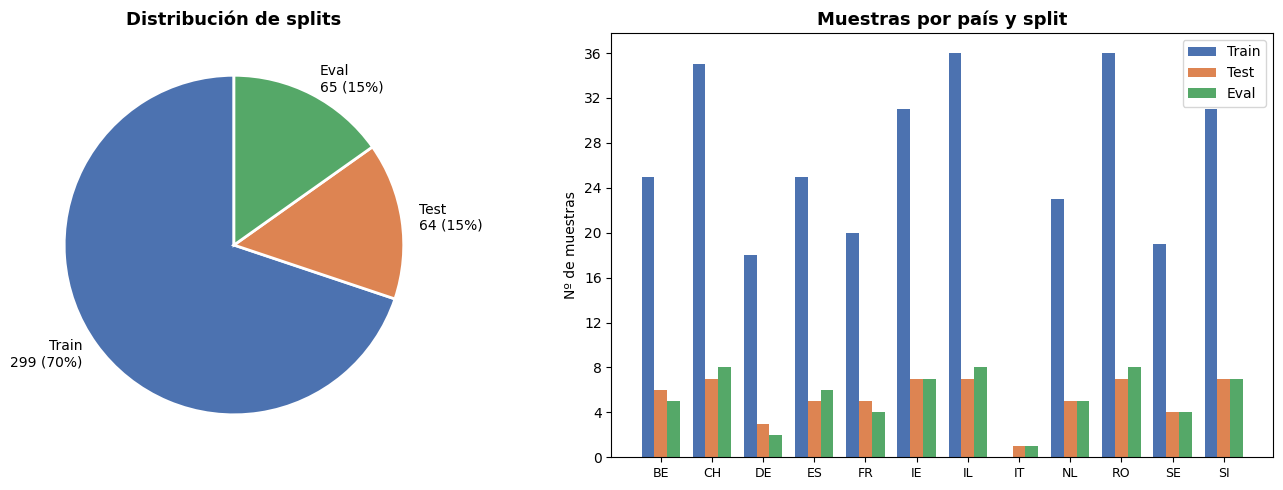

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: tamaño de splits
sizes  = [len(train), len(test), len(eval_)]
labels = [f'Train\n{len(train)} ({len(train)/len(df)*100:.0f}%)',
          f'Test\n{len(test)} ({len(test)/len(df)*100:.0f}%)',
          f'Eval\n{len(eval_)} ({len(eval_)/len(df)*100:.0f}%)']
colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0].pie(sizes, labels=labels, colors=colors,
            autopct='', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribución de splits', fontsize=13, fontweight='bold')

# Gráfico 2: distribución por país en cada split
countries = comp.index.tolist()
x = np.arange(len(countries))
w = 0.25

axes[1].bar(x - w, comp['Train'], w, label='Train', color='#4C72B0')
axes[1].bar(x,     comp['Test'],  w, label='Test',  color='#DD8452')
axes[1].bar(x + w, comp['Eval'],  w, label='Eval',  color='#55A868')

axes[1].set_xticks(x)
axes[1].set_xticklabels(countries, fontsize=9)
axes[1].set_ylabel('Nº de muestras')
axes[1].set_title('Muestras por país y split', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 6.- Guardado de los datasets

Una vez realizado todo el proceso, se procede a guardar los subconjuntos resultantes en formato .csv

In [ ]:
import os

# Quitar columna auxiliar _country antes de guardar
for d in [train, test, eval_]:
    if '_country' in d.columns:
        d.drop(columns=['_country'], inplace=True)

train.to_csv(os.path.join(OUTPUT_DIR, 'train.csv'), index=False)
test.to_csv(os.path.join(OUTPUT_DIR,  'test.csv'),  index=False)
eval_.to_csv(os.path.join(OUTPUT_DIR, 'eval.csv'),  index=False)

print("train.csv guardado:", len(train), "filas...")
print("test.csv  guardado:", len(test),  "filas...")
print("eval.csv  guardado:", len(eval_), "filas...")

✓ train.csv guardado: 299 filas
✓ test.csv  guardado: 64 filas
✓ eval.csv  guardado: 65 filas
